# Preparation

In [1]:
import os

def is_submission():
    return bool(os.getenv("KAGGLE_IS_COMPETITION_RERUN"))


def is_kaggle_env():
    return (len([k for k in os.environ.keys() if "KAGGLE" in k]) > 0) or is_submission()


if is_kaggle_env():
    ! uv pip install --system --no-index --find-links='/kaggle/input/latest-mdc-whls/whls' 'pymupdf'
    
!mkdir -p /temp

Using Python 3.11.13 environment at: /usr
Resolved 1 package in 34ms                                           
Prepared 1 package in 578ms                                              
Installed 1 package in 12ms                                 
 + pymupdf==1.26.1


# Extract texts

In [3]:
%%writefile text_extraction.py
import glob
import os
import pathlib
import re
import time
from argparse import ArgumentParser
import fitz

import lxml.etree as etree
import pandas as pd


# xml parsing is copied from:
# https://www.kaggle.com/code/yutongzhang20080108/full-regex-based-solution
def xml_kind(xml_path: pathlib.Path):
    head = xml_path.open("rb").read(2048).decode("utf8", "ignore")
    if "www.tei-c.org/ns" in head:
        return "tei"
    if re.search(r"(NLM|TaxonX)//DTD", head):
        return "jats"
    if "www.wiley.com/namespaces" in head:
        return "wiley"
    if "BioC.dtd" in head:
        return "bioc"
    return "unknown"


def xml2txt(xml_dir):
    article_ids = []
    article_texts = []
    for xml in os.listdir(xml_dir):
        xml_path = pathlib.Path(os.path.join(xml_dir, xml))
        kind = xml_kind(xml_path)
        root = etree.parse(str(xml_path)).getroot()
        if kind in ("tei", "bioc", "unknown"):
            text = " ".join(root.itertext())
        elif kind == "jats":
            elems = root.xpath("//body//sec|//ref-list")
            text = " ".join("\n".join(e.itertext()) for e in elems)
        elif kind == "wiley":
            elems = root.xpath('//*[local-name()="body"]|//*[local-name()="refList"]')
            text = " ".join("\n".join(e.itertext()) for e in elems)
        else:
            text = " ".join(root.itertext())

        article_ids.append(xml.split(".xml")[0].strip())
        article_texts.append(text)
    return pd.DataFrame({"article_id": article_ids, "text": article_texts})


def pdf2txt(pdf_dir: pathlib.Path):
    article_ids = []
    article_texts = []
    for pdf in os.listdir(pdf_dir):
        article_ids.append(pdf.split(".pdf")[0].strip())
        pdf_path = os.path.join(pdf_dir, pdf)

        with fitz.open(pdf_path) as doc:
            text = []
            for page in doc:
                page_text = page.get_text()  # type: ignore
                text.append(page_text)
            article_texts.append(f"\n{'='*60}\n".join(text))

    return pd.DataFrame({"article_id": article_ids, "text": article_texts})


def main(args: dict):
    # text extraction from pdf
    try:
        pdf_texts_df = pdf2txt(args["PDF_DIR"])
        pdf_texts_df.to_csv(args["OUTPUT_DIR"] / "texts_pdf.csv", index=False)
    except Exception as e:
        print(f"Unable to get texts (pdf):\n{e}")
        return time.time()

    # text extraction from pdf
    try:
        xml_texts_df = xml2txt(args["XML_DIR"])
        xml_texts_df.to_csv(args["OUTPUT_DIR"] / "texts_xml.csv", index=False)
    except Exception as e:
        print(f"Unable to get texts (xml):\n{e}")
        raise e

    return time.time()


if __name__ == "__main__":
    parser = ArgumentParser()
    parser.add_argument("--XML_DIR", type=pathlib.Path)
    parser.add_argument("--PDF_DIR", type=pathlib.Path)
    parser.add_argument("--OUTPUT_DIR", type=pathlib.Path)

    args = vars(parser.parse_args())
    valid_args: dict[str, bool] = {k: os.path.exists(v) for k, v in args.items()}
    assert all(
        valid_args.values()
    ), f"Invalid path is provided for:\n{[k for k, v, in valid_args.items() if v is False]}"

    time_start = time.time()
    time_end = main(args)
    solution_time = time_end - time_start

    print(f"Solution finished in {solution_time:.2f}s")


"""
\n(references|data availability (statement)?|data and methods|methods and data|availability of data (and materials?)?)\b
\b(secnerefer|(tnemetats)? ytilibaliava atad|sdohtem dna atad|atad dna sdohtem|(s?lairetam dna)? atad fo ytilibaliava)\n
"""


"""
gbif
fasta
"""

Overwriting text_extraction.py


In [4]:
if not is_submission():
    !uv run text_extraction.py \
        --XML_DIR=/kaggle/input/make-data-count-finding-data-references/train/XML \
        --PDF_DIR=/kaggle/input/make-data-count-finding-data-references/train/PDF \
        --OUTPUT_DIR=/temp
else:
    !uv run text_extraction.py \
        --XML_DIR=/kaggle/input/make-data-count-finding-data-references/test/XML \
        --PDF_DIR=/kaggle/input/make-data-count-finding-data-references/test/PDF \
        --OUTPUT_DIR=/temp

MuPDF error: unsupported error: cannot create appearance stream for  annotations

MuPDF error: unsupported error: cannot create appearance stream for  annotations

MuPDF error: unsupported error: cannot create appearance stream for  annotations

MuPDF error: unsupported error: cannot create appearance stream for  annotations

MuPDF error: unsupported error: cannot create appearance stream for  annotations

MuPDF error: unsupported error: cannot create appearance stream for  annotations

MuPDF error: unsupported error: cannot create appearance stream for  annotations

MuPDF error: unsupported error: cannot create appearance stream for  annotations

MuPDF error: unsupported error: cannot create appearance stream for  annotations

MuPDF error: unsupported error: cannot create appearance stream for  annotations

MuPDF error: unsupported error: cannot create appearance stream for  annotations

MuPDF error: unsupported error: cannot create appearance stream for  annotations

MuPDF error: uns

# Extract and classify links

In [5]:
%%writefile link_extraction.py
import glob
import os
import pathlib
import re
import time
from argparse import ArgumentParser
import os
import pathlib
import re
from typing import NamedTuple

import fitz
import numpy as np
import pandas as pd

import pandas as pd

class Metrics(NamedTuple):
    tp: int
    fp: int
    fn: int
    precision: float
    recall: float
    f1: float

    def __str__(self):
        self_dict = self._asdict()

        metrics = self_dict.keys()
        max_metric_len = len(max(metrics, key=lambda metric: len(metric)))
        values = self_dict.values()
        metric_strings = []

        for metric, value in zip(metrics, values):
            metric_strings.append(
                f"{metric.ljust(max_metric_len)}: {value if int(value) == value else round(value, 4)}"
            )
        return "\n".join(metric_strings)


class Score(NamedTuple):
    metrics: Metrics
    df: pd.DataFrame

    def __str__(self):
        return f"Metrics:\n{self.metrics}\nHead of the DataFrame:\n{self.df.head(3)}"


def score(df: pd.DataFrame, gt: pd.DataFrame, on: list[str]) -> Score:
    """
    Generic scoring function for comparing extracted results against ground truth.

    Input:
      - df: DataFrame with extracted results
      - gt: Ground truth DataFrame
      - merge_cols: List of column names to merge on
      - tag: Optional tag for the scoring run

    Output:
      - tuple with metrics (accuracy, precision, recall, f1) and DataFrame with all results and label column: "tp", "fn", "fp"
    """
    # Single outer merge with indicator
    merged_df = gt.merge(df, on=on, how="outer", indicator=True)

    # Create label column based on merge indicator
    merged_df["label"] = merged_df["_merge"].map({"both": "tp", "left_only": "fn", "right_only": "fp"})
    merged_df = merged_df.drop(columns=["_merge"])

    # Calculate counts and metrics
    tp_count = (merged_df["label"] == "tp").sum()
    fp_count = (merged_df["label"] == "fp").sum()
    fn_count = (merged_df["label"] == "fn").sum()

    precision = tp_count / (tp_count + fp_count) if (tp_count + fp_count) > 0 else 0.0
    recall = tp_count / (tp_count + fn_count) if (tp_count + fn_count) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    metrics = Metrics(tp_count, fp_count, fn_count, precision, recall, f1)
    return Score(metrics, merged_df)


def score_link_extraction(df: pd.DataFrame, gt: pd.DataFrame, on=["article_id", "dataset_id"]) -> Score:
    """Score link extraction results."""
    return score(df, gt, on)


def score_classification(df: pd.DataFrame, gt: pd.DataFrame, on=["article_id", "dataset_id", "type"]) -> Score:
    """Score classification results."""
    return score(df, gt, on)


DATA_DOIS = [
    # primary
    "https://doi.org/10.5061/dryad",
    "https://doi.org/10.5281/zenodo",
    "https://doi.org/10.5256/",
    # secondary
    "https://doi.org/10.5066/",
    "https://doi.org/10.3886/icpsr",
    # deal with it
    "https://doi.org/10.7937/",  # cancer imaging archive
    "https://doi.org/10.6073/pasta",
    "https://doi.org/10.1594/pangaea",
    "https://doi.org/10.15468/",
    "https://doi.org/10.17632/",
    "https://doi.org/10.17863/",
    "https://doi.org/10.17882/",
    "https://doi.org/10.4121/",
    "https://doi.org/10.25504/",  # FAIR
]


def clean_text(df: pd.DataFrame, text_col: str):
    ctl_char_pattern = r"[\x00-\x08\x0B\x0C\x0E-\x1F]"
    inv_char_pattern = r"[\u00AD\u200B\u200E\u200F]"
    HYPHEN = chr(8208)
    return (
        df[text_col]
        .str.normalize("NFKD")
        #### invisible characters or indentation handling
        .str.replace(inv_char_pattern, repl="", regex=True, flags=re.IGNORECASE)
        .str.replace(ctl_char_pattern, repl="", regex=True, flags=re.IGNORECASE)
        .str.replace(r"[\t\n\t\s]{2,}", " ", regex=True, flags=re.IGNORECASE)
        .str.replace(r" {2,}", " ", regex=True, flags=re.IGNORECASE)
        #### some specials...
        .str.replace(HYPHEN, "-")
        .str.replace("%5C", "\\")
    )


def extract_link_context(text, pattern=None, w_left=100, w_right=100):
    assert not pattern is None
    return text


def extract_dois(df: pd.DataFrame) -> pd.DataFrame:
    result_df = df.copy()
    result_df["text"] = clean_text(result_df, text_col="text")
    result_df["dois"] = (
        #### Basic text cleaning
        result_df["text"]
        #### doi-specific stuff
        # 10.1234/[\n]
        .str.replace(r"(10\.\d+/)[\s]([^\s,]+)", r"\1\2", regex=True, flags=re.IGNORECASE)
        # 10.1234[\n]/
        .str.replace(r"(10\.\d+)[\s](/[^\s,]+)", r"\1\2", regex=True, flags=re.IGNORECASE)
        # 10.1234/hello-[\n]world
        .str.replace(r"(10\.\d+/[^\s,]+-)[\s]([^\s,]+)", r"\1\2", regex=True, flags=re.IGNORECASE)
        # 10.1234/hello.[\n]world.my.program
        .str.replace(
            r"(10\.\d+/[^\s,]+\.)\n(([^\s,]+\.[^\s,]+\.?){1}([^\s,]?))", r"\1\2", regex=True, flags=re.IGNORECASE
        )
    )

    doi_pattern = r"10\.\d+/[^\s,?!\\;]+"
    result_df["dois"] = result_df["dois"].str.findall(doi_pattern, flags=re.IGNORECASE)

    result_df = result_df.explode("dois")
    result_df.rename(columns={"dois": "dataset_id"}, inplace=True)
    result_df.dropna(subset="dataset_id", inplace=True)

    result_df["dataset_id"] = result_df["dataset_id"].astype(str)
    result_df["dataset_id"] = result_df["dataset_id"].str.replace(r"[-.,;:!?/)\]\(\[]+$", "", regex=True)

    https_doi = lambda doi: f"https://doi.org/{str(doi).lower()}"
    result_df["dataset_id"] = result_df["dataset_id"].apply(https_doi)

    result_df = result_df.drop_duplicates(subset=["article_id", "dataset_id"])

    return result_df


def extract_accessions(df: pd.DataFrame) -> pd.DataFrame:
    result_df = df.copy()
    result_df["text"] = clean_text(result_df, text_col="text")

    accession_patterns = r"""(?x)
        [\b\(\)\[\]<{]?( # Start of the main capturing group
        # 1. GEO/SRA/ENA
        (?:SR[ARPX]\d+|ERX\d+|DRX\d+|PRJNA\d+|SAMN\d+|SAME\d+|GSE\d+|GSM\d+)
        | (?:ERS\d+|DRS\d+)
        # 2. GenBank/RefSeq
        # | (?:[A-Z]{1,2}\d{5,8})(?:\.\d+)?
        # | (?:[A-Z]{2}\d{6})(?:\.\d+)?
        # 3. UniProt
        # | (?:[OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9](?:[A-Z][A-Z0-9]{2}[0-9]){1,2})
        # | (?:[A-NR-Z][0-9][A-Z][A-Z0-9]{2}[0-9])
        # 4. ENSEMBL
        | (?:NC_\d{6}\.\d{1}|NM_\d{9})
        | (?:ENS[A-Z]{0,3}[A-Z]\d{11})
        # 5. Pfam/InterPro
        | (?:PF\d{5})
        | (?:IPR\d{6})
        # 6. CATH Codes
        | (?:[1-4]\.[1-9][0-9]?[0]\.[1-9]\d{0,3}\.[1-9]\d{0,3}[0])
        # 7. GISAID
        | (?:EPI_ISL_\d{5,})
        | (?:EPI\d{6,7})
        # 8. ChEMBL
        | (?:CHEMBL\d+)
        # # 9. PDB
        # | (?:[1-9][a-zA-Z0-9]{3}) # Changed to include uppercase letters too
        # 10. PRIDE
        | (?:PXD\d+)
        # 11. EMPIAR
        | (?:EMPIAR-\d+)
        # 12. Cellosaurus
        | (?:CVCL_[A-Z0-9]{4})
        # 13. dbSNP
        # | (?:rs\d+)
        # 14. Human Protein Atlas
        | (?:HPA\d+)
        # 15. Other Common Patterns
        | (?:E-MTAB-\d+|E-MEXP-\d+)
        | (?:E-GEOD-\d+)
        | (?:E-PROT-\d+)
        )[\b\(\)\[\]>}]? # End of the main capturing group and word boundary
        """

    result_df["assessions"] = result_df["text"].str.findall(accession_patterns, flags=re.IGNORECASE)

    result_df = result_df.explode("assessions")
    result_df.rename(columns={"assessions": "dataset_id"}, inplace=True)
    result_df.dropna(subset="dataset_id", inplace=True)

    result_df["dataset_id"] = result_df["dataset_id"].str.replace(r"[-.,;:!?/)\]\(\[]+$", "", regex=True)
    result_df = result_df.drop_duplicates(subset=["article_id", "dataset_id"])
    result_df.dropna(inplace=True)

    return result_df


def postprocess_dois(df: pd.DataFrame) -> pd.DataFrame:
    to_use_data_dois = df["dataset_id"].apply(lambda dataset_id: any(stub in dataset_id for stub in DATA_DOIS))

    to_drop_eq = df[["article_id", "dataset_id"]].apply(
        lambda row: row.article_id == row.dataset_id.strip("https://doi.org/").replace("/", "_", 1), axis=1
    )

    to_drop_stubs = df["dataset_id"].apply(
        lambda dataset_id: any(str(dataset_id).endswith(stub) for stub in DATA_DOIS)
    )

    to_drop_brackets = df[["article_id", "dataset_id"]].apply(
        lambda row: (row.dataset_id.count("(") != row.dataset_id.count(")"))
        or (row.dataset_id.count("[") != row.dataset_id.count("]"))
        or (row.dataset_id.count("<") != row.dataset_id.count(">"))
        or (row.dataset_id.count("{") != row.dataset_id.count("}")),
        axis=1,
    )
    return df[to_use_data_dois & ~(to_drop_stubs | to_drop_eq | to_drop_brackets)]


def extract_links(df: pd.DataFrame) -> pd.DataFrame:
    doi_df = postprocess_dois(extract_dois(df))
    other_df = extract_accessions(df)
    final_df = pd.concat([doi_df, other_df], axis=0)
    return final_df


def display_link_extraction(gt: pd.DataFrame, df: pd.DataFrame, drop_missing=True):
    if drop_missing:
        # articles that have "Missing" label
        missing_mask = gt[gt.type == "Missing"]["article_id"].unique()
        df = df[~df.article_id.isin(missing_mask)]
        gt = gt[~gt.article_id.isin(missing_mask)]

    score = score_link_extraction(df=df, gt=gt)
    df[["article_id", "dataset_id"]].to_csv(os.path.join(args["OUTPUT_DIR"], "pdf_extracted_links.csv"))
    gt.to_csv(os.path.join(args["OUTPUT_DIR"], "TEMP_train_labels.csv"))

    print(f"\n=== Link extraction metrics ===\n{score}")
    score.df["label_map"] = score.df.label.map({"fn": 0, "tp": 1, "fp": 2})
    score.df[["article_id", "dataset_id", "label", "label_map"]].sort_values(by=["label_map"]).drop(
        "label_map", axis=1
    ).to_csv(os.path.join(args["OUTPUT_DIR"], "score_link_extraction.csv"), index=False)


PRIMARY_DOIS = [
    "https://doi.org/10.5061/dryad",
    "https://doi.org/10.5281/zenodo",
    "https://doi.org/10.5256/",
]

SECONDARY_DOIS = ["https://doi.org/10.5066/", "https://doi.org/10.3886/icpsr"]


def is_primary(dataset_id):
    return any(primary_doi in dataset_id for primary_doi in PRIMARY_DOIS)


def is_secondary(dataset_id):
    return any(secondary_doi in dataset_id for secondary_doi in SECONDARY_DOIS) or (
        "https://doi.org" not in dataset_id
    )


def naive_classifier(df: pd.DataFrame):
    """
    Input:
        - DataFrame with article_id, dataset_id columns
    Output:
        - Labels for this DataFrame
    """

    df["type"] = [pd.NA] * len(df)

    primary_mask = df.dataset_id.apply(is_primary)
    df["type"][primary_mask] = "Primary"

    secondary_mask = df.dataset_id.apply(is_secondary)
    df["type"][secondary_mask] = "Secondary"
    
    return df.dropna(subset="type")


def submit(df: pd.DataFrame):
    submission_df = df.reset_index(drop=True).reset_index()
    submission_df["row_id"] = range(len(submission_df))
    submission_df = submission_df[["row_id", "article_id", "dataset_id", "type"]]

    submission_df.to_csv("submission.csv", index=False)
    return submission_df


def is_submission():
    return bool(os.getenv("KAGGLE_IS_COMPETITION_RERUN"))



def main(args: dict):
    # read labels
    train_labels = pd.read_csv(args["TRAIN_LABELS"])

    try:
        texts_pdf = pd.read_csv(args["PDF_TEXTS"])
        texts_xml = pd.read_csv(args["XML_TEXTS"])
        texts_df = pd.concat([texts_pdf, texts_xml], axis=0)

        all_extracted_links = extract_links(texts_df).drop_duplicates(subset=["article_id", "dataset_id"])
        if not is_submission():
            display_link_extraction(gt=train_labels, df=all_extracted_links)
        
        submission = submit(naive_classifier(all_extracted_links))
        print(submission.head(10))
    except Exception as e:
        print(f"Linked extraction failed (pdf):\n{e}")
        raise e

    return time.time()

if __name__ == "__main__":
    parser = ArgumentParser()
    parser.add_argument("--TRAIN_LABELS", type=pathlib.Path)
    parser.add_argument("--XML_TEXTS", type=pathlib.Path)
    parser.add_argument("--PDF_TEXTS", type=pathlib.Path)
    parser.add_argument("--OUTPUT_DIR", type=pathlib.Path)

    args = vars(parser.parse_args())
    valid_args: dict[str, bool] = {k: os.path.exists(v) for k, v in args.items()}
    assert all(
        valid_args.values()
    ), f"Invalid path is provided for:\n{[k for k, v, in valid_args.items() if v is False]}"

    time_start = time.time()
    time_end = main(args)
    solution_time = time_end - time_start

    print(f"Link extraction finished in {solution_time:.2f}s")

Writing link_extraction.py


In [6]:
!uv run link_extraction.py \
    --TRAIN_LABELS=/kaggle/input/make-data-count-finding-data-references/train_labels.csv \
    --XML_TEXTS=/temp/texts_xml.csv \
    --PDF_TEXTS=/temp/texts_pdf.csv \
    --OUTPUT_DIR=/temp


=== Link extraction metrics ===
Metrics:
tp       : 573
fp       : 208
fn       : 146
precision: 0.7337
recall   : 0.7969
f1       : 0.764
Head of the DataFrame:
             article_id  ... label
0  10.1002_2017jc013030  ...    fp
1  10.1002_2017jc013030  ...    tp
2     10.1002_ece3.4466  ...    tp

[3 rows x 5 columns]
/kaggle/working/link_extraction.py:309: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps u

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


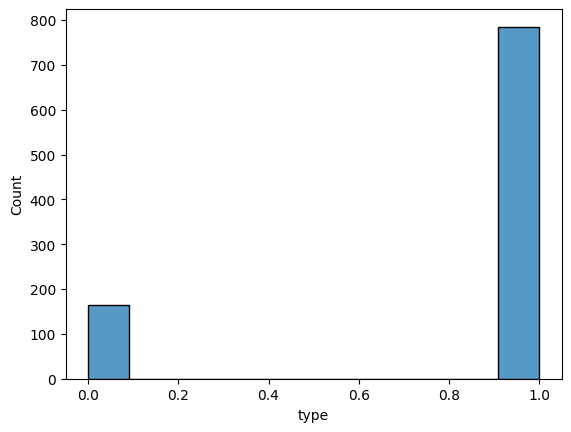

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sub = pd.read_csv("/kaggle/working/submission.csv")
sns.histplot(sub.type.map({"Primary": 0, "Secondary": 1}))
plt.show()